<a href="https://www.kaggle.com/code/sonawanelalitsunil/e-commerce-ad-spend-vs-viewer-traffic-ml-100?scriptVersionId=234765218" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/personal-ecommerce-website-ad-cost-and-viewer-count/final_website_stats.csv


## Title: E-commerce Ad Spend vs Viewer Traffic

#### Description:
Track ad costs and viewer counts to analyze your personal e-commerce site's performance.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/personal-ecommerce-website-ad-cost-and-viewer-count/final_website_stats.csv')

In [3]:
df.head()

,Unnamed: 0,timestamp,page_views,ad_spend,is_weekend,day_of_week,is_holiday
0,0,2022-01-01,1165.962767,194.901425,True,Saturday,True
1,1,2022-01-02,1191.485835,175.852071,True,Sunday,False
2,2,2022-01-03,1266.928269,269.430656,False,Monday,False
3,3,2022-01-04,1364.193858,295.690896,False,Tuesday,False
4,4,2022-01-05,1013.282520,242.975399,False,Wednesday,False


In [4]:
df.tail()

,Unnamed: 0,timestamp,page_views,ad_spend,is_weekend,day_of_week,is_holiday
1091,1091,2024-12-27,1870.700150,248.883333,False,Friday,False
1092,1092,2024-12-28,1977.793002,201.828886,True,Saturday,False
1093,1093,2024-12-29,2229.203908,181.558377,True,Sunday,False
1094,1094,2024-12-30,2286.211502,271.979202,False,Monday,False
1095,1095,2024-12-31,1992.601776,247.578503,False,Tuesday,False


In [5]:
df.describe()

,Unnamed: 0,page_views,ad_spend
count,1096.000000,1096.000000,1096.000000
mean,547.500000,1553.196104,249.518466
std,316.532252,277.144160,73.055129
min,0.000000,867.718643,113.665941
25%,273.750000,1350.935728,206.832469
50%,547.500000,1562.069595,240.465752
75%,821.250000,1746.785818,269.795000
max,1095.000000,2286.951163,679.515529


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1096 non-null   int64  
 1   timestamp    1096 non-null   object 
 2   page_views   1096 non-null   float64
 3   ad_spend     1096 non-null   float64
 4   is_weekend   1096 non-null   bool   
 5   day_of_week  1096 non-null   object 
 6   is_holiday   1096 non-null   bool   
dtypes: bool(2), float64(2), int64(1), object(2)
memory usage: 45.1+ KB


In [7]:
df.isnull().sum()

Unnamed: 0     0
timestamp      0
page_views     0
ad_spend       0
is_weekend     0
day_of_week    0
is_holiday     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Unnamed: 0       int64
timestamp       object
page_views     float64
ad_spend       float64
is_weekend        bool
day_of_week     object
is_holiday        bool
dtype: object

In [10]:
df.shape

(1096, 7)

In [11]:
df.columns

Index(['Unnamed: 0', 'timestamp', 'page_views', 'ad_spend', 'is_weekend',
       'day_of_week', 'is_holiday'],
      dtype='object')

## Data visualizations

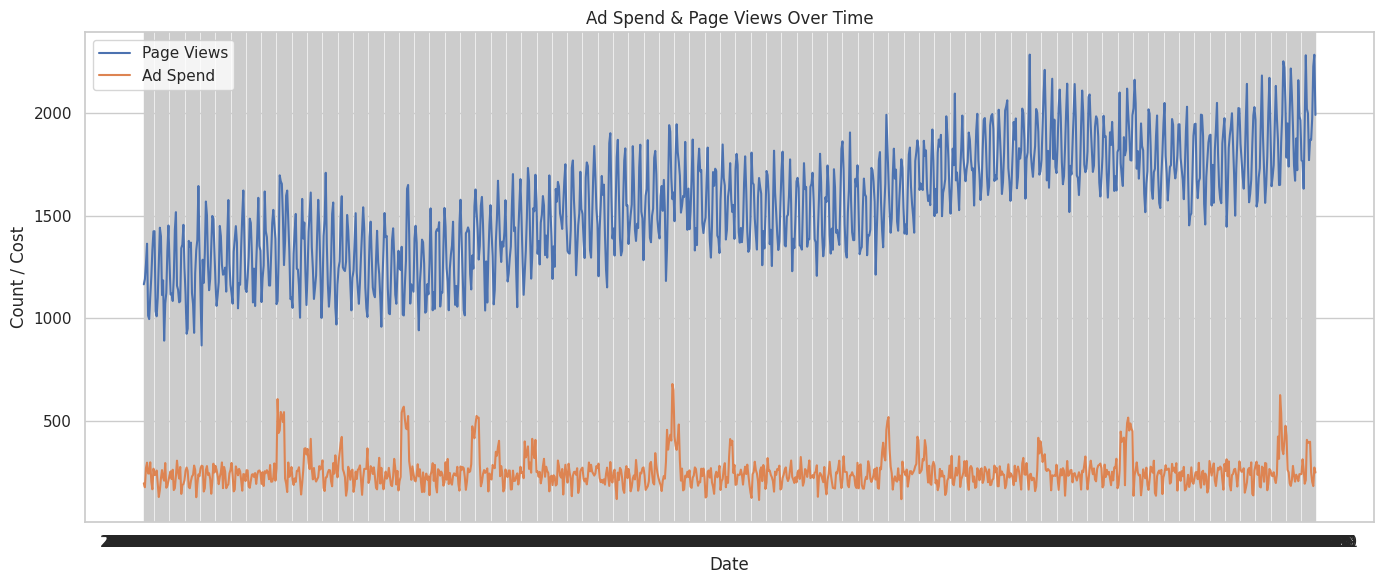

In [12]:
# Set plot style
sns.set(style='whitegrid')

# 1. Line plot: Ad spend and page views over time
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='timestamp', y='page_views', label='Page Views')
sns.lineplot(data=df, x='timestamp', y='ad_spend', label='Ad Spend')
plt.title('Ad Spend & Page Views Over Time')
plt.xlabel('Date')
plt.ylabel('Count / Cost')
plt.legend()
plt.tight_layout()
plt.show()


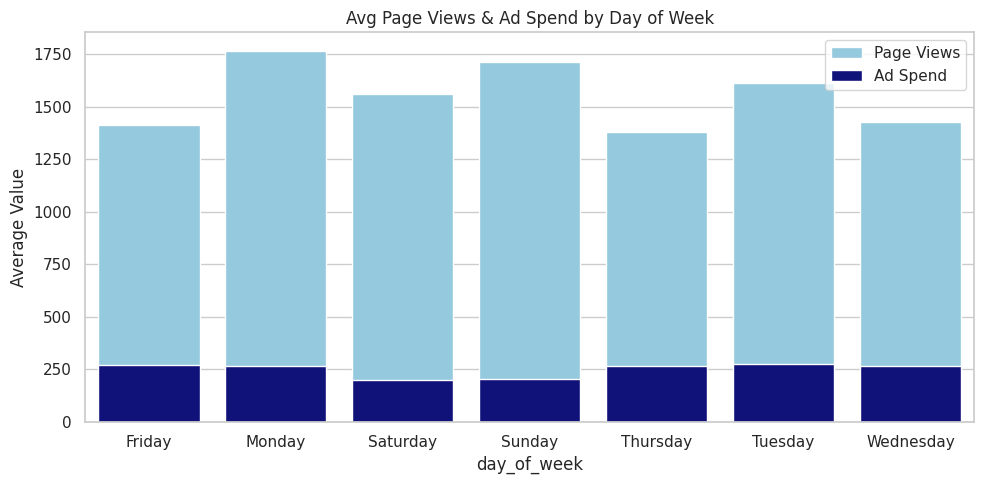

In [13]:
# 2. Bar plot: Average ad spend and page views by day of week
plt.figure(figsize=(10, 5))
grouped = df.groupby('day_of_week')[['page_views', 'ad_spend']].mean().reset_index()
grouped = grouped.sort_values('day_of_week')  # optional sorting
sns.barplot(data=grouped, x='day_of_week', y='page_views', color='skyblue', label='Page Views')
sns.barplot(data=grouped, x='day_of_week', y='ad_spend', color='darkblue', label='Ad Spend')
plt.title('Avg Page Views & Ad Spend by Day of Week')
plt.ylabel('Average Value')
plt.legend()
plt.tight_layout()
plt.show()

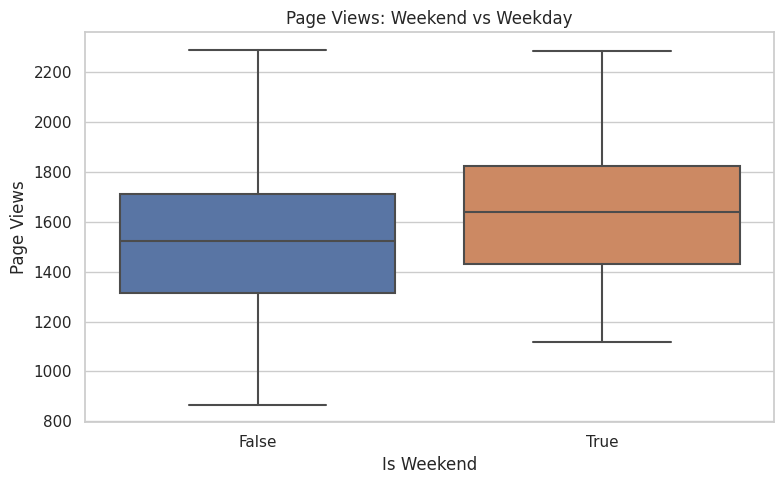

In [14]:
# 3. Box plot: Page views on weekends vs weekdays
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_weekend', y='page_views')
plt.title('Page Views: Weekend vs Weekday')
plt.xlabel('Is Weekend')
plt.ylabel('Page Views')
plt.tight_layout()
plt.show()

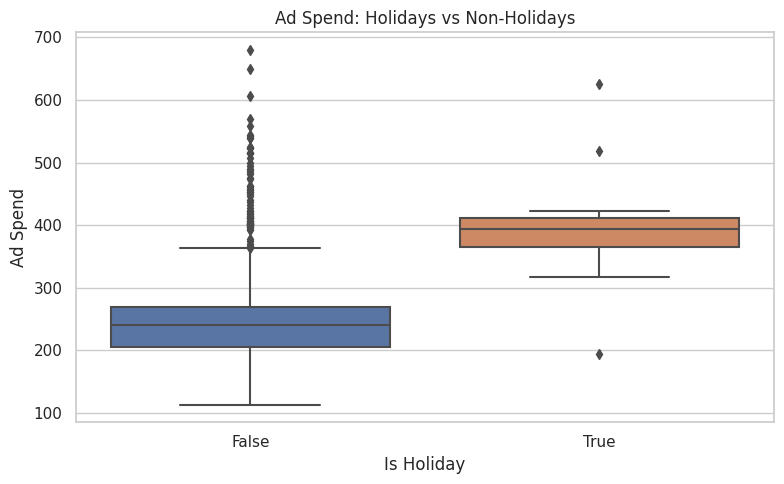

In [15]:
# 4. Box plot: Ad spend on holidays vs non-holidays
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_holiday', y='ad_spend')
plt.title('Ad Spend: Holidays vs Non-Holidays')
plt.xlabel('Is Holiday')
plt.ylabel('Ad Spend')
plt.tight_layout()
plt.show()


## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [17]:
# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Drop any rows where timestamp couldn't be parsed
df = df.dropna(subset=['timestamp'])

# Feature engineering
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

# Drop unnecessary columns
df.drop(['Unnamed: 0', 'timestamp'], axis=1, inplace=True)

# Label encoding for categorical columns (if any)
le = LabelEncoder()
if df['day_of_week'].dtype == 'object':
    df['day_of_week'] = le.fit_transform(df['day_of_week'])

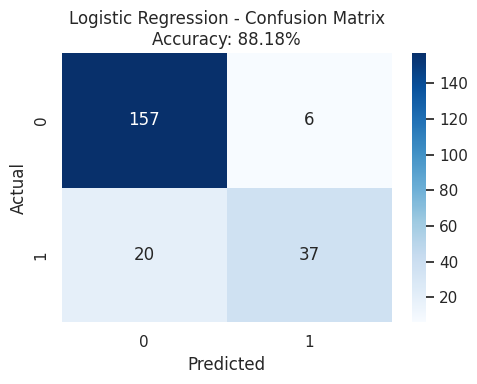

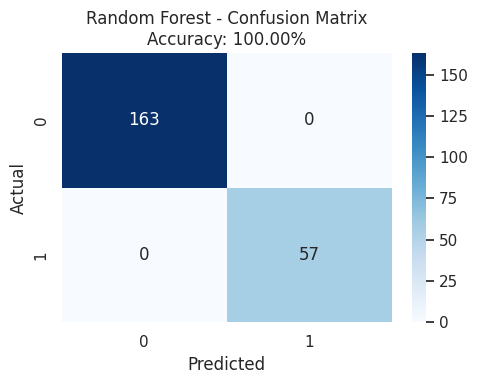

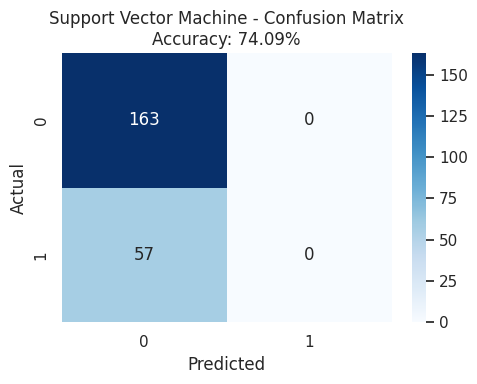

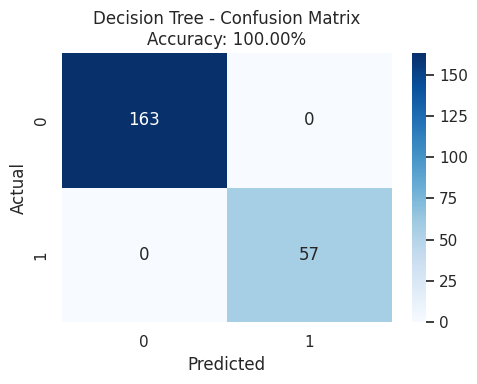

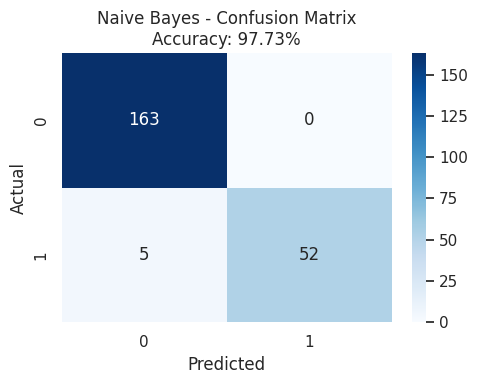

In [18]:
# Define features and target
X = df.drop('is_weekend', axis=1)
y = df['is_weekend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classifiers to apply
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

# Fit and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix\nAccuracy: {acc:.2f}%')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## Thank you..pls upvote!!